### Stochastic interpolant with **equivariant OT**: ideal chain → tangentially active polymer

A tangentially active polymer (TAP) is a bead-spring chain driven by a force along its own
local backbone tangent. Two features set it apart from the LJ13 cluster, and both are visible
in the code below:

* **It is a directed object.** The active force follows the chain from tail to head, so
  relabelling monomers is *not* a symmetry. The OT coupling therefore optimizes over **O(3)
  alone** — no permutation layer — and the velocity field carries a chain-index node feature
  so that it can tell monomer 1 from monomer 7 at all.
* **It is out of equilibrium.** The drive is non-conservative: there is no potential $U(x)$,
  no Boltzmann target, and no free energy to reweight toward. Nothing in this notebook
  computes $\Delta F$, because no importance-sampling estimator exists to compute it with.
  The interpolant entropy is the point — it is reachable precisely where reweighting is not.

Translations are gauge-fixed by pinning the **tail** (particle 0) at the origin, so
configurations live on a $3(N-1)$-dimensional subspace and rotations act about that pinned
point rather than about the centroid.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.systems.tap.data import (
    REF_DATA_PATH, load_ref_data, sample_prior, log_prior,
    bond_vectors, end_to_end_sq, gyration_sq, bond_sigma, dof,
)
from eesi.systems.tap.dynamics import TAPDynamics, rk4_sample, integrate_with_logdet
from eesi.systems.tap.ot import tap_ot_couple, tap_cost_matrix
from eesi.systems.tap.train import make_si_model, train_si, tap_step
from eesi.ot import transport_cost

%matplotlib inline
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [22]:
N       = 20        # monomers
RE_SQR  = 48.0612       # mean squared end-to-end distance of the ideal-chain prior
DOF     = dof(N)    # 3 (N-1) = 57

def bond_lengths(x):                     # (B,N,3) -> (B*(N-1),)
    return bond_vectors(x).norm(dim=-1).reshape(-1).cpu().numpy()

# <u_i . u_{i+k}> for unit bond tangents: the shape signature of an active chain.
# An ideal chain decorrelates immediately (delta_{k0}); activity stiffens the backbone
# and makes this decay slowly, so it is the cleanest single curve for telling the
# prior and the target apart.
def tangent_correlation(x):
    u = bond_vectors(x)
    u = u / u.norm(dim=-1, keepdim=True)
    nb = u.shape[1]
    return np.array([(u[:, :nb-k] * u[:, k:]).sum(-1).mean().item() for k in range(nb)])

def smooth(v, k=10):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

# Apply a sampler to x0 in chunks: the ODE/SDE have no batch coupling, so this is
# exactly equivalent to one big call and only caps peak GPU memory.
@torch.no_grad()
def chunked(fn, x0, size=500):
    return torch.cat([fn(c) for c in x0.split(size)])

### 1. Datasets & samplers

The base distribution is an **ideal (Gaussian) chain**: $N-1$ iid isotropic bond vectors with
$\mathbb{E}|b|^2 = \mathrm{ReSqr}/(N-1)$, positions given by their cumulative sum from the
pinned tail. Its log-density is exact — the bond-to-position map is unit lower triangular, so
no Jacobian correction appears:

$$\log p_0(x) = -\frac{1}{2\sigma^2}\sum_{k}|x_k - x_{k-1}|^2 - \frac{3(N-1)}{2}\log(2\pi\sigma^2),
\qquad \sigma^2 = \frac{\mathrm{ReSqr}}{3(N-1)}.$$

In [3]:
# --- prior sanity: the convention is that ReSqr IS the mean squared end-to-end distance ---
x0_check = sample_prior(200_000, RE_SQR, n_particles=N)
print(f"E[Re^2]  = {end_to_end_sq(x0_check).mean():.4f}   (ReSqr = {RE_SQR})")
print(f"E[Rg^2]  = {gyration_sq(x0_check).mean():.4f}   (ideal chain: ReSqr/6 = {RE_SQR/6:.4f})")
print(f"E[|b|^2] = {(bond_vectors(x0_check)**2).sum(-1).mean():.5f}   (ReSqr/(N-1) = {RE_SQR/(N-1):.5f})")

# the analytic entropy of the prior, as a reference point for section 5
sigma2 = bond_sigma(RE_SQR, N) ** 2
S_prior = 0.5 * DOF * (1.0 + np.log(2 * np.pi * sigma2))
print(f"\nS[p0] (analytic) = {S_prior:+.4f} nats     -E[log p0] = {-log_prior(x0_check, RE_SQR).mean():+.4f}")
del x0_check

E[Re^2]  = 47.9841   (ReSqr = 48.0612)
E[Rg^2]  = 8.3979   (ideal chain: ReSqr/6 = 8.0102)
E[|b|^2] = 2.52879   (ReSqr/(N-1) = 2.52954)

S[p0] (analytic) = +76.0181 nats     -E[log p0] = +76.0097


In [6]:
# --- target: the reference TAP configurations ---
#
# Generated externally (Brownian dynamics of the active chain) and written as a .npy of
# shape (M, N, 3) or (M, N*3), tail already at the origin. Point `DATA` wherever yours is.
DATA = REF_DATA_PATH
n_data = 100_000

if pathlib.Path(DATA).exists():
    x1 = load_ref_data(DATA, n=n_data, n_particles=N).to(device)
    USING_PLACEHOLDER = False
else:
    # ---------------------------------------------------------------------------
    # PLACEHOLDER so the notebook is runnable before the real trajectories land.
    # A semiflexible chain: correlated bond directions, which is qualitatively what
    # activity does to the backbone, but it is NOT active-polymer data. Every number
    # below is meaningless until the cell above finds a real file.
    # ---------------------------------------------------------------------------
    USING_PLACEHOLDER = True
    print(f"!! {DATA} not found -- using a SEMIFLEXIBLE PLACEHOLDER, not real TAP data\n")
    g = torch.Generator().manual_seed(0)
    b = torch.randn(n_data, N - 1, 3, generator=g)
    for k in range(1, N - 1):                      # exponential tangent correlation
        b[:, k] = 0.75 * b[:, k - 1] + np.sqrt(1 - 0.75 ** 2) * b[:, k]
    b = b * bond_sigma(RE_SQR, N)
    x1 = torch.cat([torch.zeros(n_data, 1, 3), b.cumsum(1)], dim=1).to(device)

print("target dataset:", tuple(x1.shape))
print(f"E[Re^2] = {end_to_end_sq(x1).mean():.4f}   E[Rg^2] = {gyration_sq(x1).mean():.4f}")

target dataset: (100000, 20, 3)
E[Re^2] = 44.2769   E[Rg^2] = 6.8514


In [7]:
vals = end_to_end_sq(x1).cpu()
print(vals[0:10])

tensor([ 39.5501,  62.0243,  19.7520,  18.0155,  25.5942,  21.2310,   1.2527,
        130.2672, 138.6093,  88.7256])


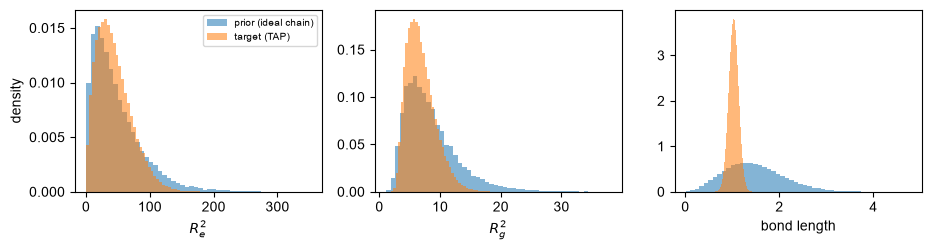

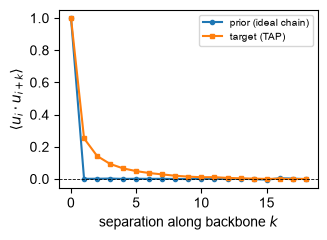

In [9]:
# --- prior vs target: where the flow has to do work ---
x0_ref = sample_prior(20_000, RE_SQR, n_particles=N, device=device)

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.6))
for a, (v0, v1, lab) in zip(ax, [
    (end_to_end_sq(x0_ref).cpu(), end_to_end_sq(x1).cpu(), r"$R_e^2$"),
    (gyration_sq(x0_ref).cpu(),   gyration_sq(x1).cpu(),   r"$R_g^2$"),
    (bond_lengths(x0_ref),        bond_lengths(x1),        "bond length"),
]):
    a.hist(np.asarray(v0), bins=50, density=True, alpha=0.55, label="prior (ideal chain)")
    a.hist(np.asarray(v1), bins=50, density=True, alpha=0.55, label="target (TAP)")
    a.set_xlabel(lab)
ax[0].set_ylabel("density"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

fig, a = plt.subplots(figsize=(3.375, 2.5))
a.plot(tangent_correlation(x0_ref), 'o-', ms=3, label="prior (ideal chain)")
a.plot(tangent_correlation(x1[:20_000]), 's-', ms=3, label="target (TAP)")
a.axhline(0, c="k", lw=0.6, ls="--")
a.set_xlabel("separation along backbone $k$"); a.set_ylabel(r"$\langle u_i \cdot u_{i+k}\rangle$")
a.legend(fontsize=7); plt.tight_layout(); plt.show()

### 2. The coupling

`tap_ot_couple` optimizes over **O(3)** and the batch assignment. Two things it deliberately
does *not* do, both checked in `tests/tap/test_tap_ot.py`:

* it never **centers** — rotations act about the pinned tail, and centering would push the
  chain off the subspace the prior and the divergence basis are defined on;
* it never **permutes** monomers — that would identify configurations the active dynamics
  distinguishes.

Because the permutation stage is gone, orthogonal Procrustes solves the whole group exactly,
so unlike LJ13 the alignment here is *exactly* equivariant.

In [29]:
batch_size = 256
torch.manual_seed(1)

idx = torch.randint(0, x1.shape[0], (batch_size,), device=device)
xb  = x1[idx]
xa  = sample_prior(batch_size, RE_SQR, n_particles=N, device=device)

cells_2x2 = {}
for align in (True, False):
    for batch in (True, False):
        a, b = tap_ot_couple(xa, xb, align=align, batch=batch)
        cells_2x2[(align, batch)] = transport_cost(a, b).item()

base = cells_2x2[(False, False)]
print(f"{'align':>6} {'batch':>6} {'transport':>11} {'vs random':>10}")
for (al, ba), c in cells_2x2.items():
    print(f"{str(al):>6} {str(ba):>6} {c:11.4f} {100*(c/base-1):9.1f}%")

a, b = tap_ot_couple(xa, xb)
print(f"\ntail row after coupling: |x0[:,0]| = {a[:,0].abs().max():.2e}, "
      f"|x1[:,0]| = {b[:,0].abs().max():.2e}   (must be 0: the gauge is pinned)")

 align  batch   transport  vs random
  True   True     62.0285     -92.9%
  True  False    186.1075     -78.7%
 False   True    168.5521     -80.7%
 False  False    873.4780       0.0%

tail row after coupling: |x0[:,0]| = 0.00e+00, |x1[:,0]| = 0.00e+00   (must be 0: the gauge is pinned)


### 3. Training with equivariant OT

Two `TAPDynamics` fields (drift and score) share the LJ13 E(n)-GNN backbone from `eesi.egnn`.
The wrapper differs in two ways: the output velocity is projected onto $\{v : v_0 = 0\}$ rather
than onto the COM-free subspace, and each node carries its **normalized chain index**
$i/(N-1)$ alongside the time. Without that index the network is $S(N)$-equivariant and
literally cannot represent a directed chain's velocity field — flip `index_feature=False`
to see it fail.

In [31]:
torch.manual_seed(2)
batch_size = 512
model = make_si_model(n_particles=N, n_dims=3, hidden_nf=24, n_layers=4,
                      index_feature=True, path="linear", gamma="sqrt",
                      gamma_scale=0.2, learn_score=False)
model = model.to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

parameters: 34,236


In [32]:
torch.manual_seed(3)
t_start = time.perf_counter()

model, htot = train_si(x1, RE_SQR, model=model, steps=1_000, batch=batch_size,
                       lr=1e-3, device=str(device), log_every=10)
model, hist = train_si(x1, RE_SQR, model=model, steps=1_000, batch=batch_size,
                       lr=1e-4, device=str(device), log_every=10)
htot += hist
hist_b, hist_s = map(np.asarray, zip(*htot))
print(f"total {time.perf_counter()-t_start:.0f}s")

torch.save(model.net_b.state_dict(), f"tap_b_si_N{N}_B{batch_size}.pth")
torch.save(model.net_s.state_dict(), f"tap_s_si_N{N}_B{batch_size}.pth")
print(f"saved tap_{{b,s}}_si_N{N}_B{batch_size}.pth")

  step     0  loss_b  415.2315  loss_s 1211.5698  transport  50.190  (  0.9s)
  step    10  loss_b   63.8124  loss_s  225.9735  transport  53.013  (  7.0s)
  step    20  loss_b    9.3181  loss_s   52.7055  transport  56.107  ( 13.1s)
  step    30  loss_b    0.1329  loss_s    6.4691  transport  51.223  ( 19.3s)
  step    40  loss_b   -0.3763  loss_s   -1.5272  transport  53.955  ( 25.4s)
  step    50  loss_b   -2.4307  loss_s   -8.8875  transport  49.515  ( 31.6s)
  step    60  loss_b   -3.0330  loss_s  -12.1273  transport  52.763  ( 37.7s)
  step    70  loss_b   -2.4495  loss_s  -14.7776  transport  50.786  ( 43.9s)
  step    80  loss_b   -3.6577  loss_s  -16.8184  transport  52.974  ( 50.0s)
  step    90  loss_b   -3.2959  loss_s  -18.4077  transport  55.247  ( 56.1s)
  step   100  loss_b   -3.6363  loss_s  -20.5323  transport  53.389  ( 62.3s)
  step   110  loss_b   -3.0963  loss_s  -22.7076  transport  53.499  ( 68.5s)
  step   120  loss_b   -3.5046  loss_s  -23.9655  transport  53.

KeyboardInterrupt: 

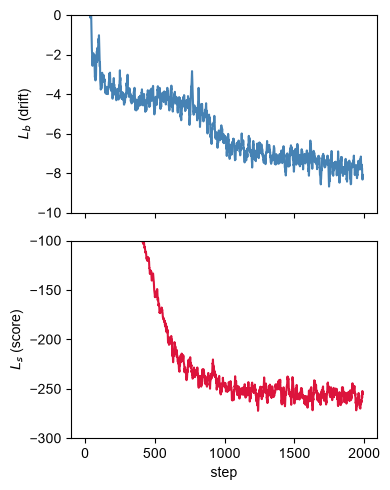

In [35]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), c="steelblue"); ax[0].set_ylabel(r"$L_b$ (drift)")
ax[1].plot(smooth(hist_s), c="crimson");   ax[1].set_ylabel(r"$L_s$ (score)")
ax[1].set_xlabel("step")
#for a in ax: a.set_yscale("symlog")
ax[0].set_ylim(-10,0)
ax[1].set_ylim(-300,-100)
plt.tight_layout(); plt.show()

### 4. Sampling

In [36]:
torch.manual_seed(4)
n_gen = 1_000
x0 = sample_prior(n_gen, RE_SQR, n_particles=N, device=device)
x_gen = chunked(lambda c: rk4_sample(model.net_b, c, n_steps=100), x0)

print(f"generated {tuple(x_gen.shape)}   tail |x[:,0]| = {x_gen[:,0].abs().max():.2e}")
print(f"{'':<10}{'E[Re^2]':>10}{'E[Rg^2]':>10}")
for name, s in [("prior", x0), ("generated", x_gen), ("reference", x1[:n_gen])]:
    print(f"{name:<10}{end_to_end_sq(s).mean():10.3f}{gyration_sq(s).mean():10.3f}")

generated (1000, 20, 3)   tail |x[:,0]| = 0.00e+00
             E[Re^2]   E[Rg^2]
prior         48.512     8.481
generated     45.813     7.148
reference     46.266     6.984


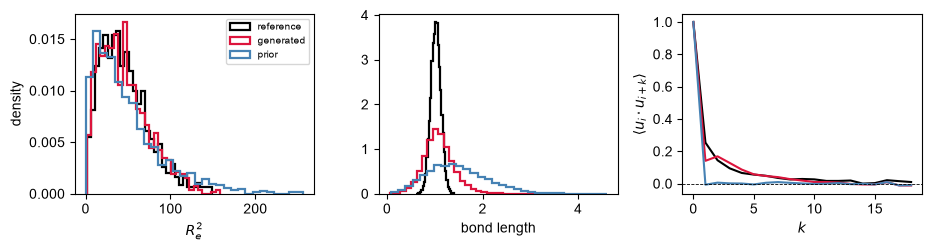

In [37]:
series = [(x1[:n_gen], "reference", "k"), (x_gen, "generated", "crimson"),
          (x0,        "prior",     "steelblue")]

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.6))
for s, lab, c in series:
    ax[0].hist(end_to_end_sq(s).cpu().numpy(), bins=30, density=True,
               histtype="step", lw=1.6, color=c, label=lab)
    ax[1].hist(bond_lengths(s), bins=30, density=True,
               histtype="step", lw=1.6, color=c, label=lab)
    ax[2].plot(tangent_correlation(s), '-', c=c, label=lab)
ax[0].set_xlabel(r"$R_e^2$"); ax[1].set_xlabel("bond length")
ax[2].set_xlabel("$k$"); ax[2].set_ylabel(r"$\langle u_i \cdot u_{i+k}\rangle$")
ax[2].axhline(0, c="k", lw=0.6, ls="--")
ax[0].set_ylabel("density"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 5. Entropy estimates

The quantity of interest, and the reason for the whole construction: $\Delta S$ from prior to
target. Both interpolant estimators are available (`"dot"`, the inner product $b\cdot s$, and
`"div"`, the exact subspace divergence over the $3(N-1)$ anchored directions).

There is **no free-energy cross-check here**, unlike the LJ13 notebook. That is not an
omission — an active polymer has no target potential, so $-\log \tilde p_1(x)$ does not exist
and no importance-weighted estimate of $\Delta F$ can be formed. The absolute entropy of the
target follows from the prior's analytic entropy plus the measured change:
$S[p_1] = S[p_0] + \Delta S$.

In [ ]:
torch.manual_seed(5)
n_batches = 100
means_dot, means_div = [], []
for _ in range(n_batches):
    idx = torch.randint(0, x1.shape[0], (batch_size,), device=device)
    xb = x1[idx]
    xa = sample_prior(batch_size, RE_SQR, n_particles=N, device=device)
    xa, xb = tap_ot_couple(xa, xb)
    means_dot.append(model.entropy_estimate(xb, xa, method="dot").mean().item())
    means_div.append(model.entropy_estimate(xb, xa, method="div").mean().item())

ci = lambda v: 1.96 * np.std(v) / np.sqrt(len(v))
print(f"dS (b.s)   : {np.mean(means_dot):+.3f} +/- {ci(means_dot):.3f}")
print(f"dS (div b) : {np.mean(means_div):+.3f} +/- {ci(means_div):.3f}")
print(f"\nS[p0] (analytic) = {S_prior:+.3f}")
print(f"S[p1] = S[p0] + dS = {S_prior + np.mean(means_div):+.3f} nats")

In [ ]:
# Running entropy change along many ODE paths.
torch.manual_seed(6)
x0 = sample_prior(1_000, RE_SQR, n_particles=N, device=device)
_, ent_div, ts = model.sample(x0, n_steps=50, return_traj=True, entropy='div')
_, ent_dot, _  = model.sample(x0, n_steps=50, return_traj=True, entropy='dot')
ts_c = ts.cpu().numpy()
ent_c_div, ent_c_dot = ent_div.cpu().numpy(), ent_dot.cpu().numpy()

fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.plot(ts_c, ent_c_div.mean(axis=1), c="crimson", lw=2.5, label="divergence")
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="steelblue", lw=2.5, label="inner")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
if USING_PLACEHOLDER:
    print("REMINDER: this run used the semiflexible placeholder, not real TAP trajectories.\n"
          "Point DATA at the generated .npy and re-run from section 1.")